In [16]:
import numpy as np

from ml_tools.models.model_loss import MSELoss
from ml_tools.models.optimizers import SGD, Adam
from ml_tools.models.layers.layers import (
    FrequencyFFT,
    FullyConnectedLayer,
    DropoutLayer,
    NormalizeLayer,
    RMSNormLayer
)
from ml_tools.models.layers.operators import LatentStack, LatentSum, ShiftRight
from ml_tools.models.layers.mixture_layers import PoolingLayer
from ml_tools.models.blocks import SpectreAttention, CausalSpectreAttention
from ml_tools.models.embedding.positional import SinusoidEmbedding

import matplotlib.pyplot as plt

MAX_POSSIBLE_WINDOWS = 2**10


In [17]:
from ml_tools.encoders.audio_encoders import AudioProcessor, read_wav, window_size_from_ms, plot_waveform, plot_spectrogram, plot_window_spectra, build_windows, progressive_downsample

WINDOW_LENGTH_MS = 800 # our window length
sample_rate, waveform_l = read_wav("../test.wav", channel=0)
sample_rate, waveform_r = read_wav("../test.wav", channel=1)

time_per_sample = 1000 / sample_rate
samples_per_window = window_size_from_ms(sample_rate, WINDOW_LENGTH_MS)
# samples_per_window = WINDOW_LENGTH_MS / time_per_sample
real_positive_fft_shape = (samples_per_window // 2) + 1


print(time_per_sample, "ms per sample step")
print(f"Each {WINDOW_LENGTH_MS} ms window will be composed of {samples_per_window} samples")
print(f"Fourier Transform will yield {real_positive_fft_shape} frequency bins")

audio_enc = AudioProcessor(
    sample_rate=sample_rate,
    window_ms = WINDOW_LENGTH_MS,
    overlap_ratio= 1/3, # how much of the window is overlapping with previous step
    use_decibels = True,
    target = "waveform",
    variable_idx = 0
)


encoded_data = audio_enc.fit_encode(waveform_l)
print(audio_enc.metadata)
print("amplitude", encoded_data["amplitude"].shape, "\nfrequency spectrum:", encoded_data["spectrum"].shape)


0.010416666666666666 ms per sample step
Each 800 ms window will be composed of 76800 samples
Fourier Transform will yield 38401 frequency bins
{'target': 'waveform', 'variable_idx': 0, 'sample_rate': 96000, 'window_ms': 800, 'window_size': 76800, 'num_overlap': 25600, 'num_frequencies': 537614, 'use_decibels': True}
amplitude (14, 76800) 
frequency spectrum: (14, 38401)


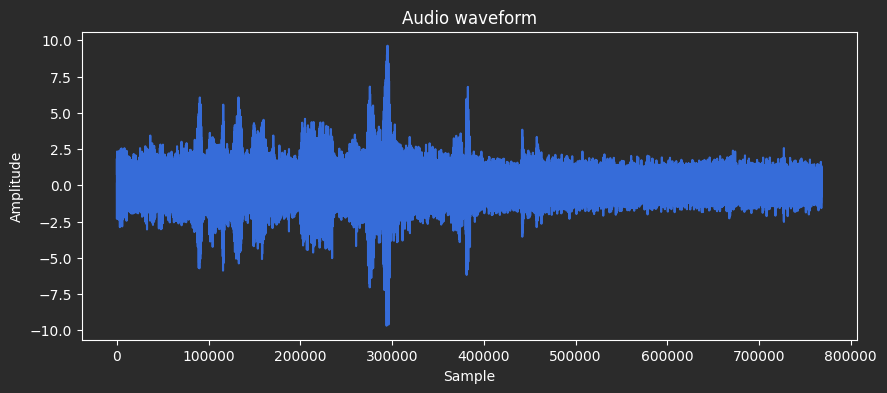

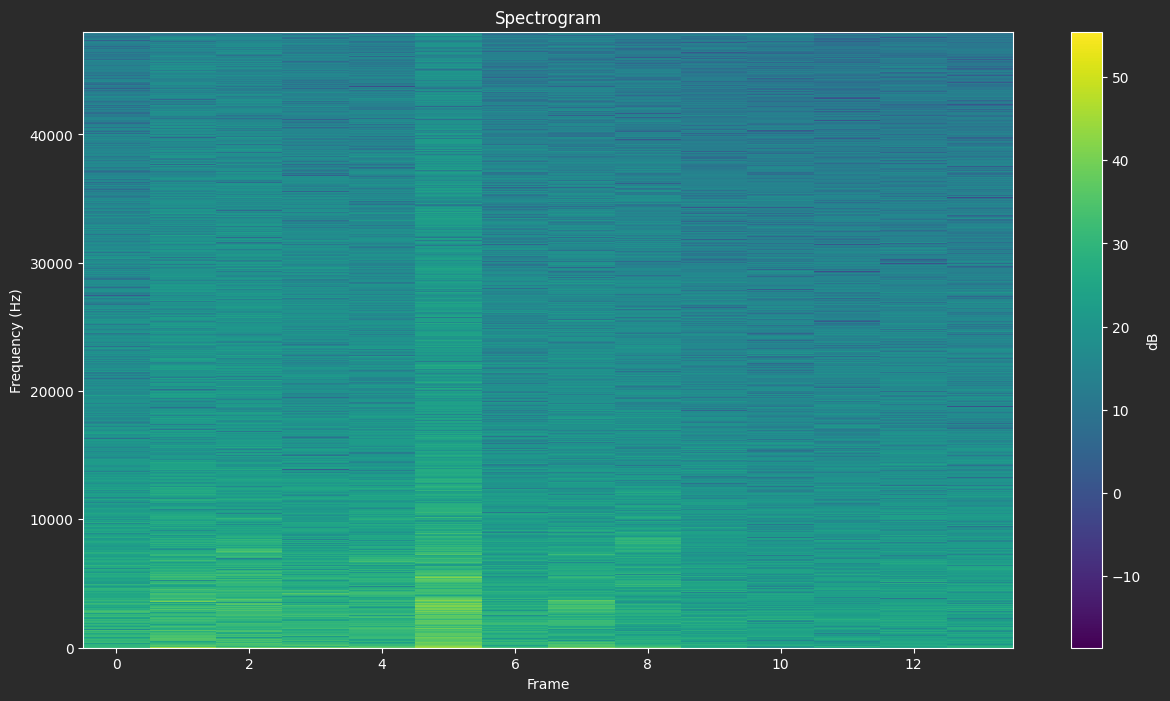

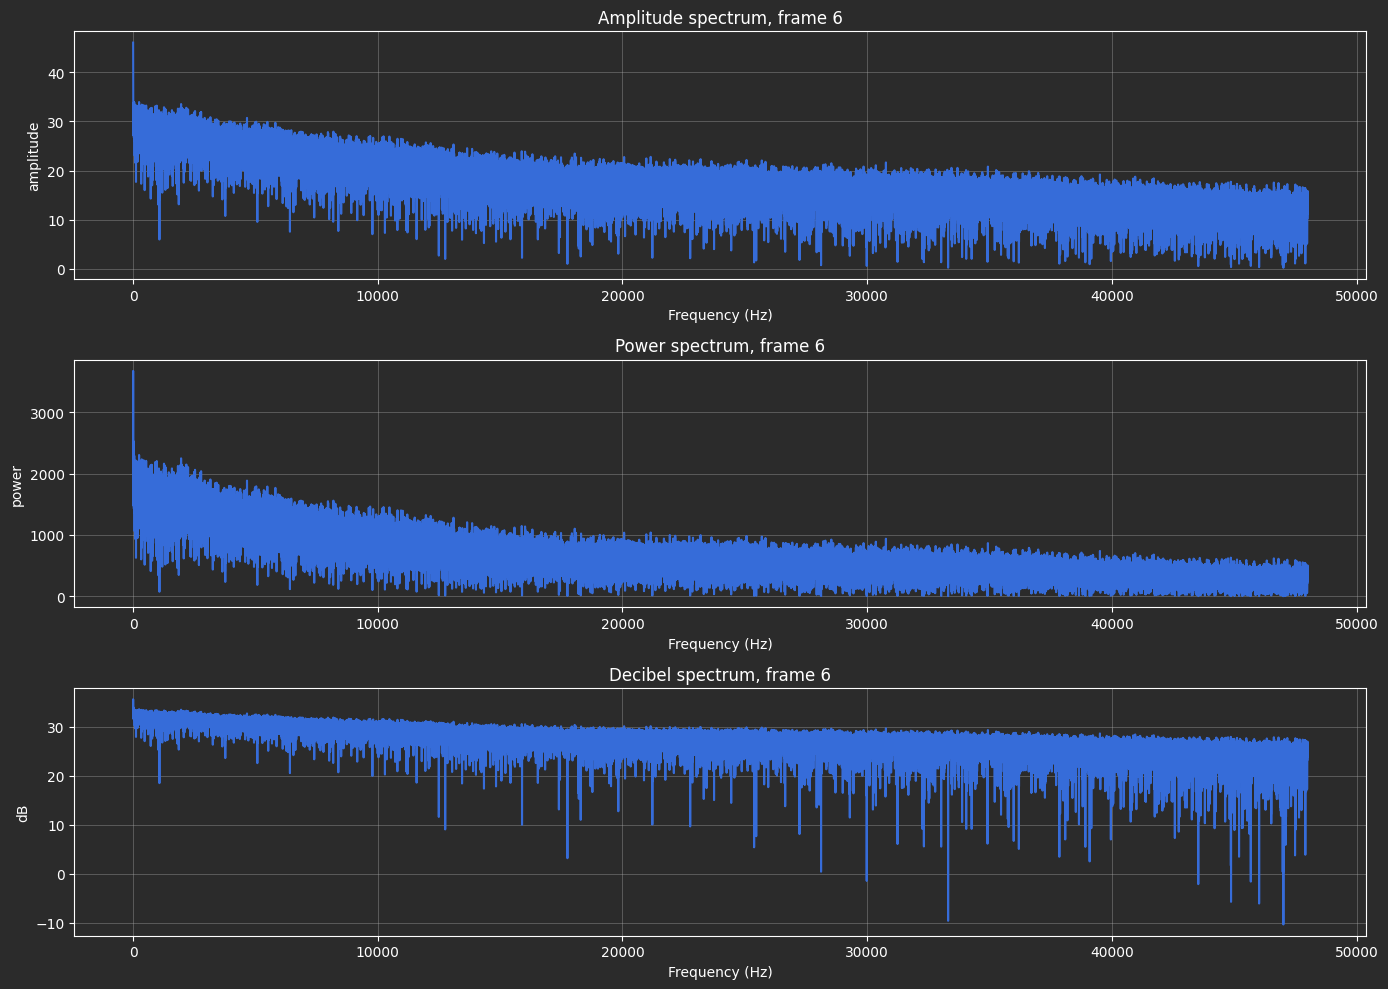

In [18]:
plot_waveform(waveform_l)
plot_spectrogram(encoded_data["spectrum"].real, audio_enc.freqs)
plot_window_spectra(
        encoded_data["spectrum"].real, audio_enc.freqs, index=6, window_size=time_per_sample
    )


In [19]:
# loading our audio files:
import os
WINDOW_LENGTH_MS = 50 # our window length

all_windowed_data = []

all_filenames = os.listdir(f"../data/")
for fn in all_filenames:
    if fn.endswith(".wav"):

        sample_rate, waveform_l = read_wav(f"../data/{fn}", channel=0)
        time_per_sample = 1000 / sample_rate
        samples_per_window = window_size_from_ms(sample_rate, WINDOW_LENGTH_MS)
        # samples_per_window = WINDOW_LENGTH_MS / time_per_sample
        real_positive_fft_shape = (samples_per_window // 2) + 1


        audio_enc = AudioProcessor(
            sample_rate=sample_rate,
            window_ms = WINDOW_LENGTH_MS,
            overlap_ratio= 1/3, # how much of the window is overlapping with previous step
            use_decibels = True,
            target = "waveform",
            variable_idx = 0
        )

        encoded_data_l = audio_enc.fit_encode(waveform_l)["amplitude"]
        list_of_array = [encoded_data_l]

        try:
            sample_rate, waveform_r = read_wav(f"../data/{fn}", channel=1)
            encoded_data_r = audio_enc.fit_encode(waveform_r)["amplitude"]
            list_of_array.append(encoded_data_r)
        except:
            pass

        all_windowed_data.extend(list_of_array)

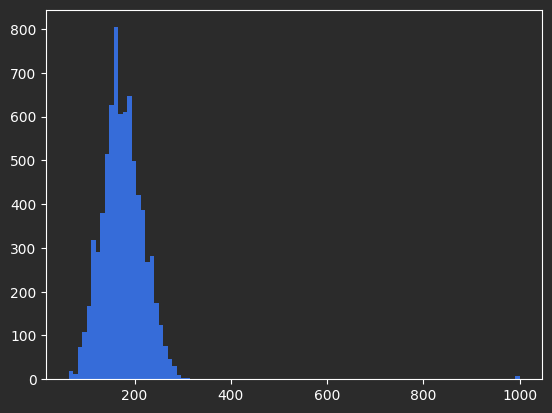

[243, 226, 179, 204, 175, 181, 191, 144, 242, 224, 223, 192, 189, 148, 228, 184, 154, 132, 158, 156, 178, 218, 129, 216, 133, 227, 192, 204, 89, 174, 194, 150, 201, 95, 202, 157, 186, 135, 239, 148, 208, 163, 173, 164, 178, 205, 157, 189, 129, 232, 204, 168, 195, 122, 166, 155, 205, 212, 126, 200, 249, 175, 162, 210, 223, 178, 178, 221, 245, 132, 111, 120, 157, 203, 260, 165, 200, 211, 140, 174, 144, 147, 246, 206, 140, 185, 220, 210, 223, 195, 149, 156, 221, 168, 127, 132, 161, 180, 111, 118, 119, 188, 162, 177, 133, 166, 285, 218, 177, 283, 159, 168, 154, 165, 152, 126, 186, 125, 153, 181, 188, 120, 103, 189, 180, 155, 218, 171, 173, 127, 127, 238, 217, 213, 111, 145, 159, 187, 166, 222, 213, 202, 201, 163, 131, 157, 104, 158, 151, 235, 160, 113, 137, 213, 225, 173, 174, 165, 173, 121, 185, 249, 186, 198, 160, 157, 141, 203, 154, 185, 199, 182, 176, 126, 193, 201, 158, 225, 196, 245, 170, 203, 183, 193, 169, 170, 243, 162, 94, 119, 89, 124, 108, 171, 228, 168, 188, 238, 170, 145, 157

In [20]:
shapes = []
np.random.shuffle(all_windowed_data)

for windowed_data in all_windowed_data:
    shapes.append(windowed_data.shape[0])

plt.hist(np.clip(shapes, min=0, max=1000), bins=100)
plt.show()
print(shapes)
print(np.max(shapes))

In [21]:
# MAX_POSSIBLE_WINDOWS should be optimized for specific lengths of FFT: closest to: (2**10 * N)
MAX_POSSIBLE_WINDOWS = 2**10 * 1


# pad our sequences to max:
xs = np.zeros((len(all_windowed_data), MAX_POSSIBLE_WINDOWS, samples_per_window))
padding_mask = np.zeros((len(all_windowed_data), MAX_POSSIBLE_WINDOWS))
for idx, data in enumerate(all_windowed_data):
    l, n = data.shape
    l = min(l, MAX_POSSIBLE_WINDOWS)
    xs[idx, :l, :] = data[:l, ...]
    padding_mask[idx, :l] = 1

print(xs.shape)
print(padding_mask.shape)

(7504, 1024, 200)
(7504, 1024)


In [7]:
# Grab a subset and downsample:

# xs = xs[:250, ...]
# padding_mask = padding_mask[:250, ...]

downs = progressive_downsample(xs, mask=padding_mask, factors=[2, 2, 2])

for dim in downs:
    print(dim[0].shape, dim[1].shape)

(250, 1024, 200) (250, 1024)
(250, 512, 200) (250, 512)
(250, 256, 200) (250, 256)
(250, 128, 200) (250, 128)


In [22]:
print(xs.shape, padding_mask.shape)

(7504, 1024, 200) (7504, 1024)


In [23]:
MAX_POSSIBLE_WINDOWS

1024

Automatic pdb calling has been turned ON
edges:
  input      -> amp_a
  amp_a      -> amp_b
  amp_b      -> amp_c
  input      -> freq_fft
  freq_fft   -> freq_fc
  amp_c      -> stack
  freq_fc    -> stack
  stack      -> position
  position   -> project
  project    -> enc1_attn
  enc1_attn  -> enc1_drop
  enc1_drop  -> enc1_a
  project    -> enc2_latentconn
  enc1_a     -> enc2_latentconn
  enc2_latentconn -> enc2_prenorm
  enc2_prenorm -> enc2_attn
  enc2_attn  -> enc2_drop
  enc2_drop  -> enc2_a
  project    -> enc3_latentconn
  enc2_a     -> enc3_latentconn
  enc3_latentconn -> enc3_prenorm
  enc3_prenorm -> enc3_attn
  enc3_attn  -> enc3_drop
  enc3_drop  -> enc3_a
  project    -> latentresid
  enc3_a     -> latentresid
  latentresid -> latent_prenorm
  latent_prenorm -> latentproj
  latentproj -> pooler
  pooler     -> latent_norm
  project    -> shift_right
  shift_right -> teacher_dropout
  latent_norm -> decoder_projection
  decoder_projection -> decoder_input
  teacher_drop

<Axes: title={'center': 'audio_encoder_decoder'}>

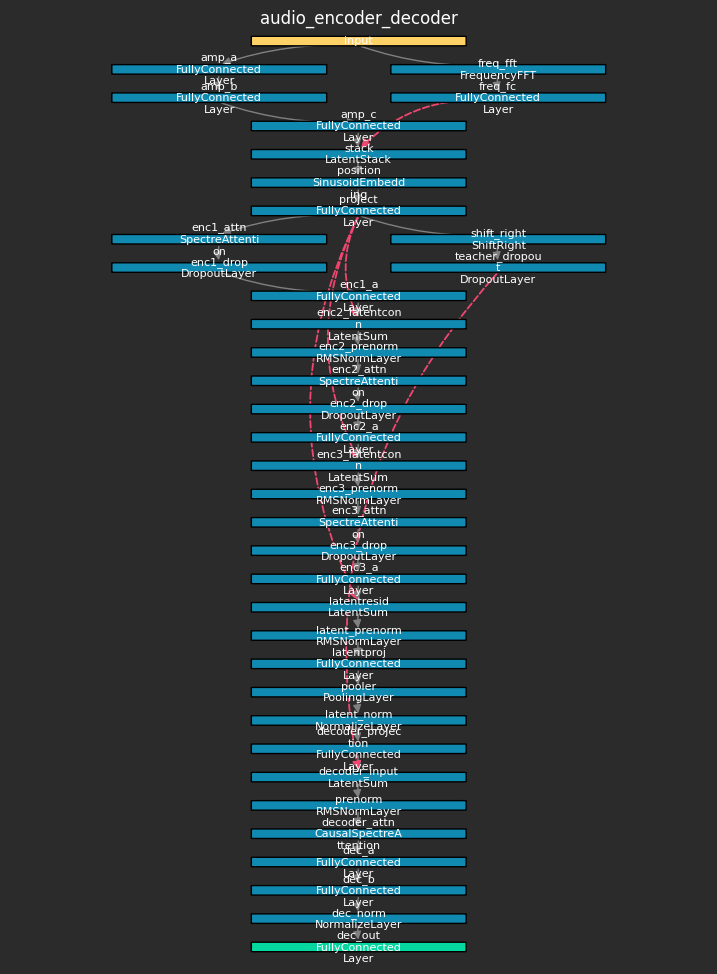

In [10]:
from ml_tools.models.neural_network import Node, NeuralNetwork
from ml_tools.visuals.nnet_visuals import plot_network
%pdb on

EMBEDDING_DIM = 800
HIDDEN_DIM = 512
NUM_HEADS=8
# latent space bottleneck
LATENT_DIMENSION = 1200

# samples_per_window = the samples per window (final dimesion of xs)

net = NeuralNetwork(name="audio_encoder_decoder", input_shape=((samples_per_window,),))
windows = net.input

# amplitude branch: funnel the raw window down to the latent width
amplitude = net.connect(FullyConnectedLayer(samples_per_window, EMBEDDING_DIM, "relu"), windows, name="amp_a")
amplitude = net.connect(FullyConnectedLayer(EMBEDDING_DIM, real_positive_fft_shape, "relu"), amplitude, name="amp_b")
amplitude = net.connect(FullyConnectedLayer(real_positive_fft_shape, EMBEDDING_DIM, "linear"), amplitude, name="amp_c")

# frequency branch. `windows` is used a second time here, which is the fan-out
frequency = net.connect(FrequencyFFT(MAX_POSSIBLE_WINDOWS, samples_per_window), windows, name="freq_fft")
frequency = net.connect(FullyConnectedLayer(samples_per_window, EMBEDDING_DIM, "linear"), frequency, name="freq_fc")

# the branches merge, then get positional information
mixed = net.connect(LatentStack(), amplitude, frequency, name="stack")
mixed = net.connect(SinusoidEmbedding(MAX_POSSIBLE_WINDOWS, 2 * EMBEDDING_DIM), mixed, name="position")
mixed = net.connect(FullyConnectedLayer(2*EMBEDDING_DIM, HIDDEN_DIM, "linear"), mixed, name="project")

# encoder
enc1 = net.connect(SpectreAttention(sequence_length=MAX_POSSIBLE_WINDOWS, hidden_dim=HIDDEN_DIM, num_heads=NUM_HEADS), mixed, name="enc1_attn")
enc1 = net.connect(DropoutLayer(dropout_prob=0.05), enc1, name="enc1_drop")
enc1 = net.connect(FullyConnectedLayer(HIDDEN_DIM, HIDDEN_DIM, "relu"), enc1, name="enc1_a")

# encoder2 ------------------
enc2 = net.connect(LatentSum(), mixed, enc1, name="enc2_latentconn")
enc2 = net.connect(RMSNormLayer(ni=HIDDEN_DIM), enc2, name="enc2_prenorm")
enc2 = net.connect(SpectreAttention(sequence_length=MAX_POSSIBLE_WINDOWS, hidden_dim=HIDDEN_DIM, num_heads=NUM_HEADS), enc2, name="enc2_attn")
enc2 = net.connect(DropoutLayer(dropout_prob=0.05), enc2, name="enc2_drop")
enc2 = net.connect(FullyConnectedLayer(HIDDEN_DIM, HIDDEN_DIM, "relu"), enc2, name="enc2_a")


#  encoder3 ------------------
enc3 = net.connect(LatentSum(), mixed, enc2, name="enc3_latentconn")
enc3 = net.connect(RMSNormLayer(ni=HIDDEN_DIM), enc3, name="enc3_prenorm")
enc3 = net.connect(SpectreAttention(sequence_length=MAX_POSSIBLE_WINDOWS, hidden_dim=HIDDEN_DIM, num_heads=NUM_HEADS), enc3, name="enc3_attn")
enc3 = net.connect(DropoutLayer(dropout_prob=0.05), enc3, name="enc3_drop")
enc3 = net.connect(FullyConnectedLayer(HIDDEN_DIM, HIDDEN_DIM, "relu"), enc3, name="enc3_a")


#  Latent ------------------
latent = net.connect(LatentSum(), mixed, enc3, name="latentresid")
latent = net.connect(RMSNormLayer(HIDDEN_DIM), latent, name="latent_prenorm")
latent = net.connect(FullyConnectedLayer(HIDDEN_DIM, LATENT_DIMENSION, "linear"), latent, name="latentproj")
pooler = net.connect(PoolingLayer(), latent, name="pooler")
pooler = net.connect(NormalizeLayer(LATENT_DIMENSION), pooler, name="latent_norm")


# DECODER ------------------
shifted = net.connect(ShiftRight(hidden_dim=HIDDEN_DIM), mixed, name="shift_right")
shifted_noisy = net.connect(DropoutLayer(dropout_prob=0.33), shifted, name="teacher_dropout")

latent_broadcast = net.connect(FullyConnectedLayer(LATENT_DIMENSION, HIDDEN_DIM, "linear"), pooler,
                      name="decoder_projection")

decoded = net.connect(LatentSum(), latent_broadcast, shifted_noisy, name="decoder_input")
decoded = net.connect(RMSNormLayer(HIDDEN_DIM), decoded, name="prenorm")
decoded = net.connect(CausalSpectreAttention(sequence_length=MAX_POSSIBLE_WINDOWS,
                                             hidden_dim=HIDDEN_DIM,
                                             num_heads=NUM_HEADS,
                                             band_radius=2,
                                             max_frequency=128), decoded, name="decoder_attn")
decoded = net.connect(FullyConnectedLayer(HIDDEN_DIM, HIDDEN_DIM, "relu"), decoded, name="dec_a")
decoded = net.connect(FullyConnectedLayer(HIDDEN_DIM, HIDDEN_DIM, "relu"), decoded, name="dec_b")
decoded = net.connect(NormalizeLayer(HIDDEN_DIM, shift_scale=True), decoded, name="dec_norm")
# CausalSpectreAttention
# TODO: reconstruct sequence
net.output = net.connect(FullyConnectedLayer(HIDDEN_DIM, samples_per_window, "linear", is_output=True), decoded, name="dec_out")


print("edges:")
for producer, consumer in net.edges():
    print(f"  {producer:10s} -> {consumer}")
print()
print(net.summary(xs[0:2, :, :]))
print(net.timing_summary(top=10))
plot_network(net)


step 1462  reconstruction loss 51.113045
step 1462  reconstruction loss 51.113045


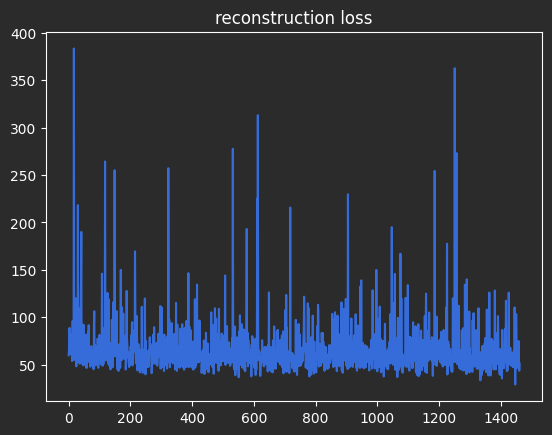

1462
step 1463  reconstruction loss 30.600952
step 1463  reconstruction loss 30.600952


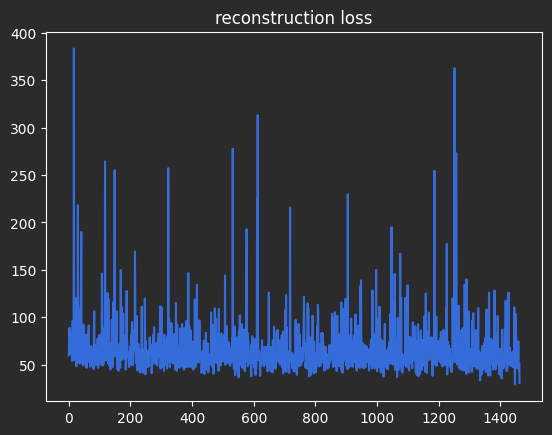

1463
step 1464  reconstruction loss 78.416393
step 1464  reconstruction loss 78.416393


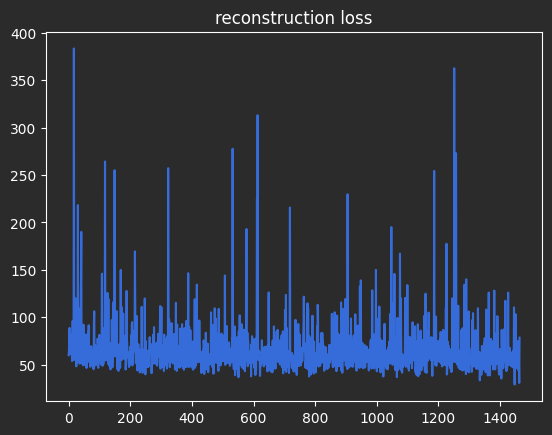

1464
step 1465  reconstruction loss 55.401371
step 1465  reconstruction loss 55.401371


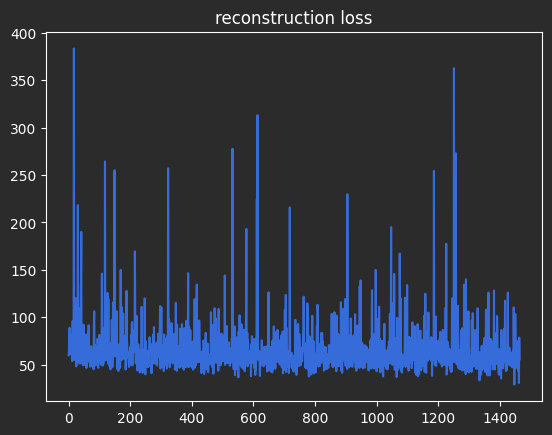

1465
step 1466  reconstruction loss 52.604843
step 1466  reconstruction loss 52.604843


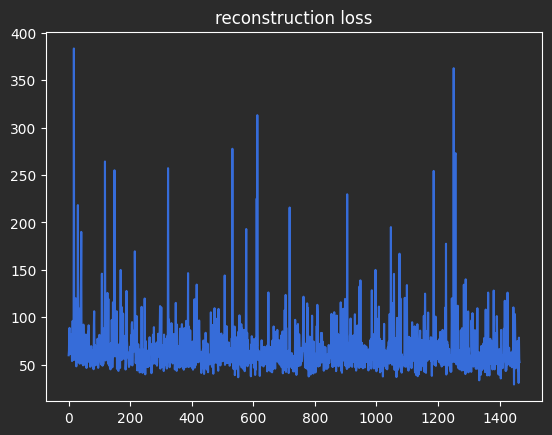

1466
step 1467  reconstruction loss 41.824074
step 1467  reconstruction loss 41.824074


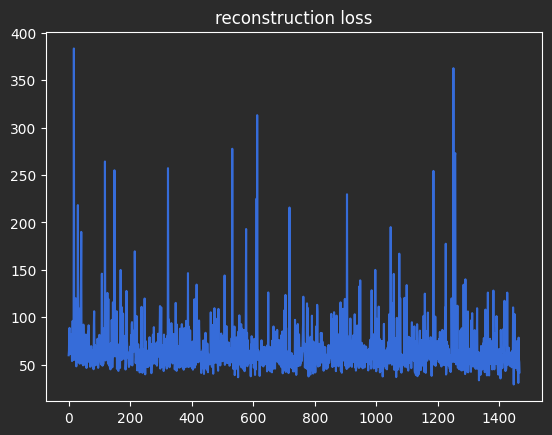

1467
step 1468  reconstruction loss 77.657304
step 1468  reconstruction loss 77.657304


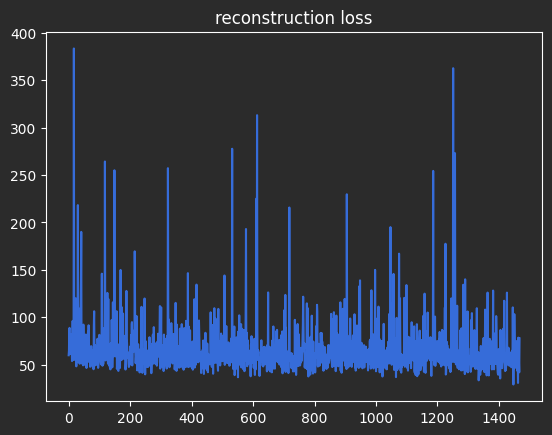

1468
step 1469  reconstruction loss 79.244032
step 1469  reconstruction loss 79.244032


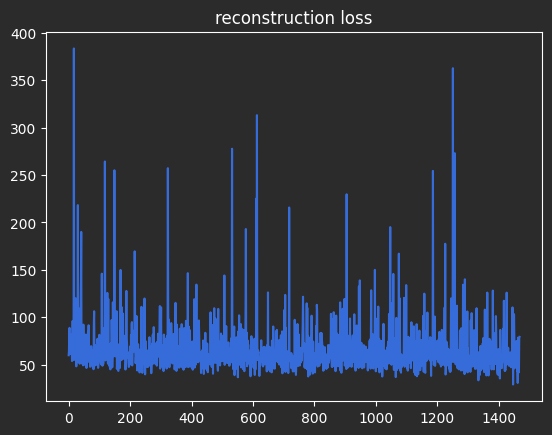

1469
step 1470  reconstruction loss 50.432110
step 1470  reconstruction loss 50.432110


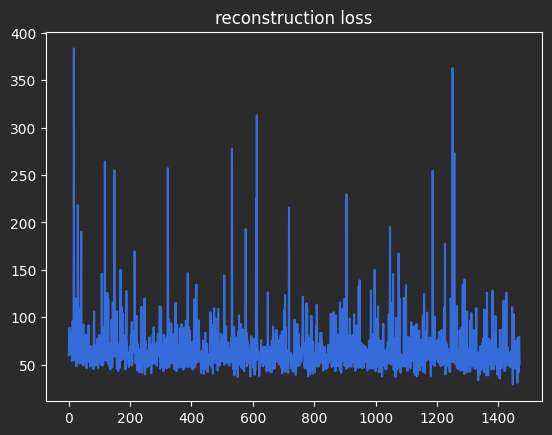

1470
step 1471  reconstruction loss 86.678299
step 1471  reconstruction loss 86.678299


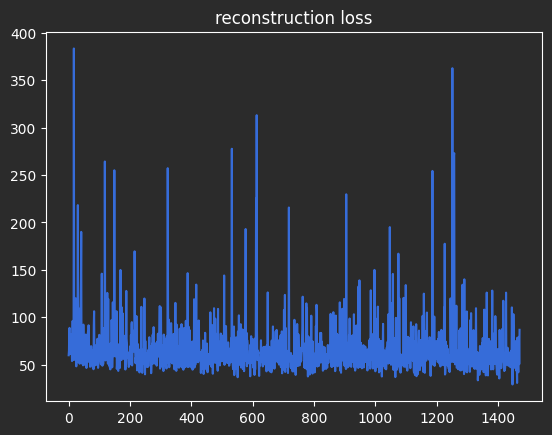

1471
step 1472  reconstruction loss 53.150835
step 1472  reconstruction loss 53.150835


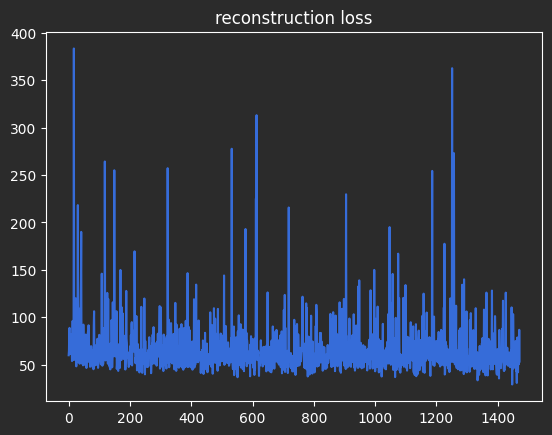

1472
step 1473  reconstruction loss 57.634783
step 1473  reconstruction loss 57.634783


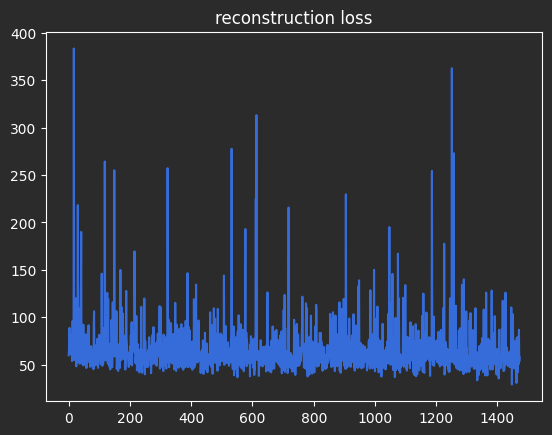

1473
step 1474  reconstruction loss 55.455537
step 1474  reconstruction loss 55.455537


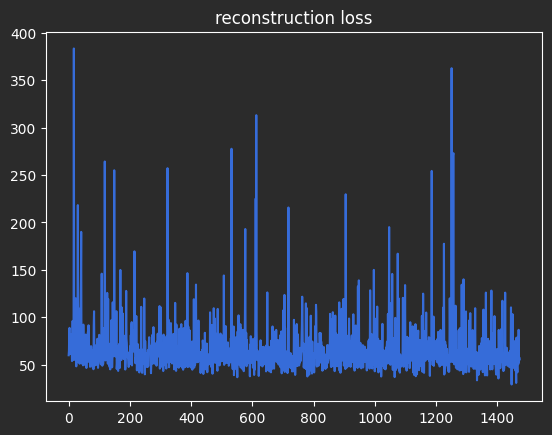

1474
step 1475  reconstruction loss 67.340614
step 1475  reconstruction loss 67.340614


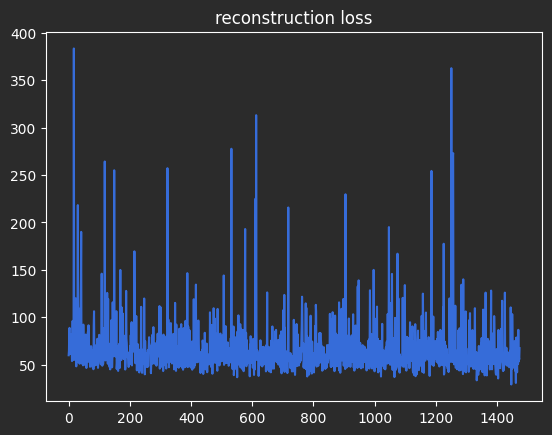

1475
step 1476  reconstruction loss 42.483368
step 1476  reconstruction loss 42.483368


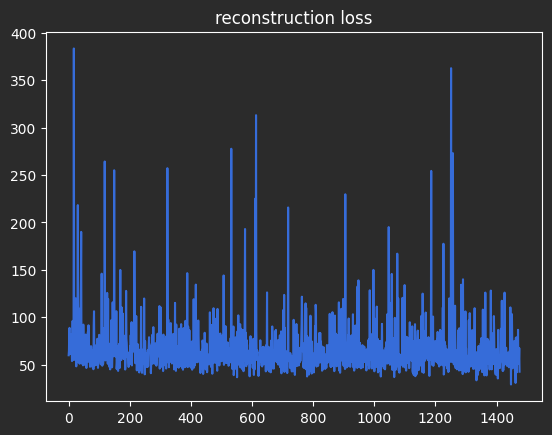

1476
step 1477  reconstruction loss 92.469218
step 1477  reconstruction loss 92.469218


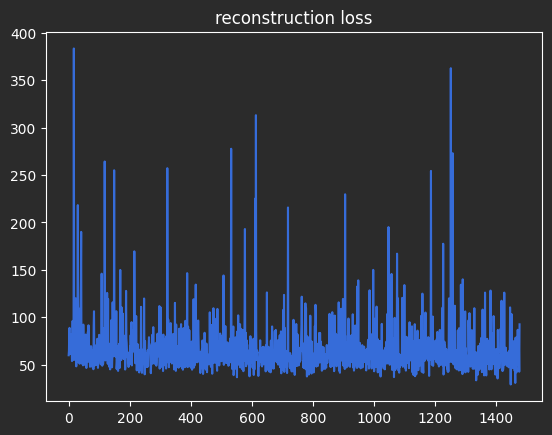

1477
step 1478  reconstruction loss 62.064020
step 1478  reconstruction loss 62.064020


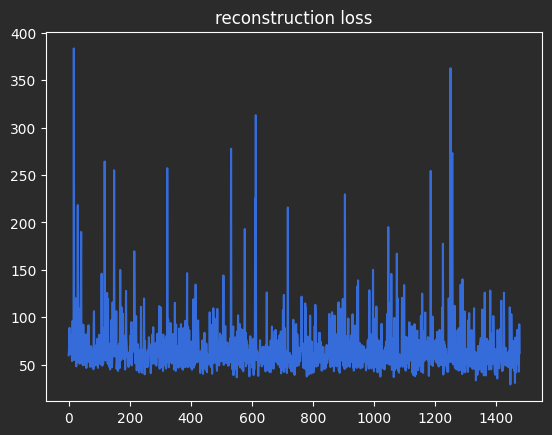

1478
step 1479  reconstruction loss 69.991966
step 1479  reconstruction loss 69.991966


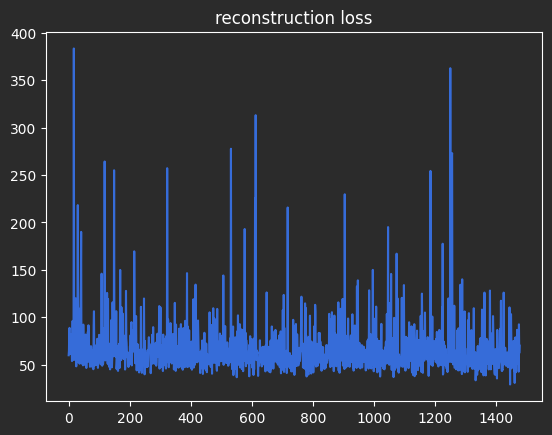

1479
step 1480  reconstruction loss 53.480489
step 1480  reconstruction loss 53.480489


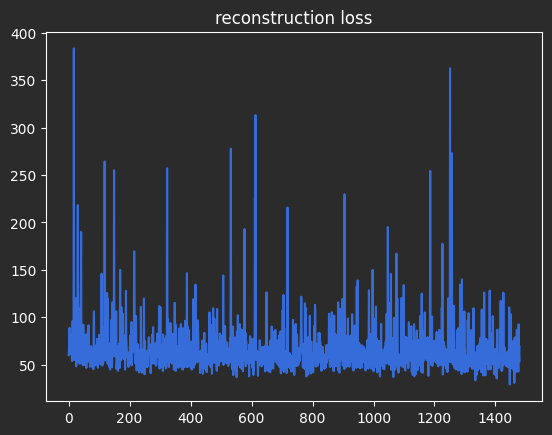

1480
step 1481  reconstruction loss 60.277263
step 1481  reconstruction loss 60.277263


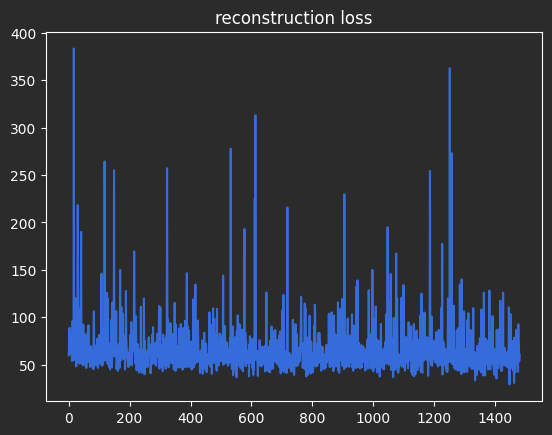

1481
step 1482  reconstruction loss 55.136586
step 1482  reconstruction loss 55.136586


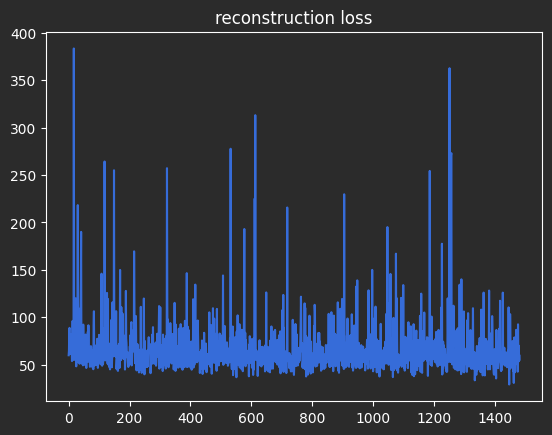

1482
step 1483  reconstruction loss 63.928511
step 1483  reconstruction loss 63.928511


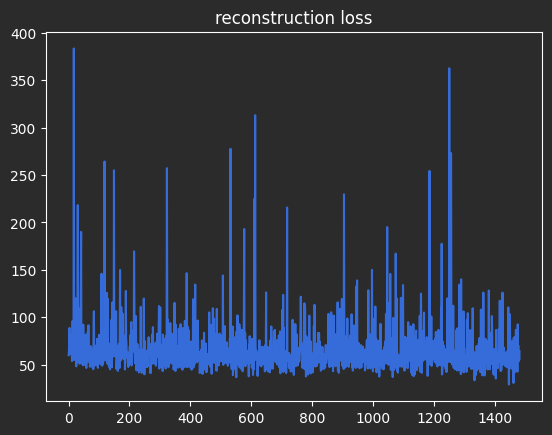

1483
step 1484  reconstruction loss 48.018303
step 1484  reconstruction loss 48.018303


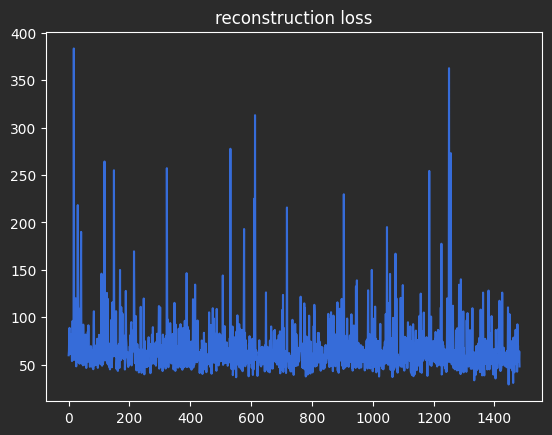

1484
step 1485  reconstruction loss 66.792871
step 1485  reconstruction loss 66.792871


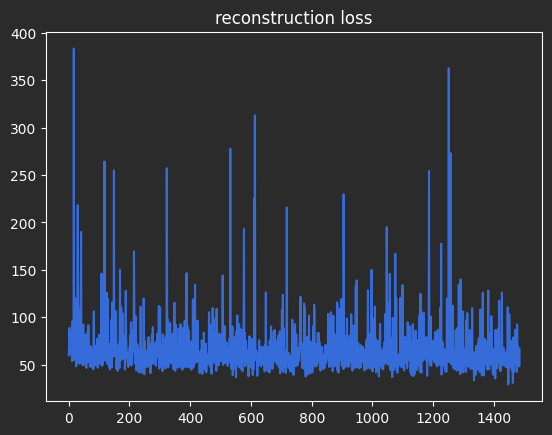

1485
step 1486  reconstruction loss 108.681169
step 1486  reconstruction loss 108.681169


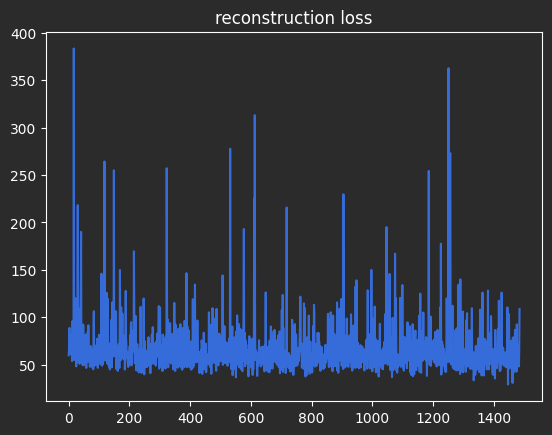

1486
step 1487  reconstruction loss 42.031911
step 1487  reconstruction loss 42.031911


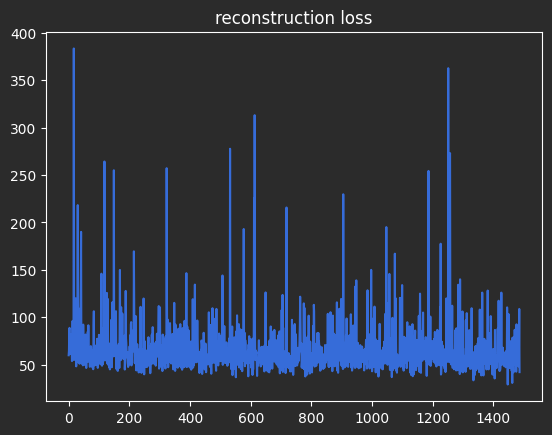

1487
step 1488  reconstruction loss 80.747696
step 1488  reconstruction loss 80.747696


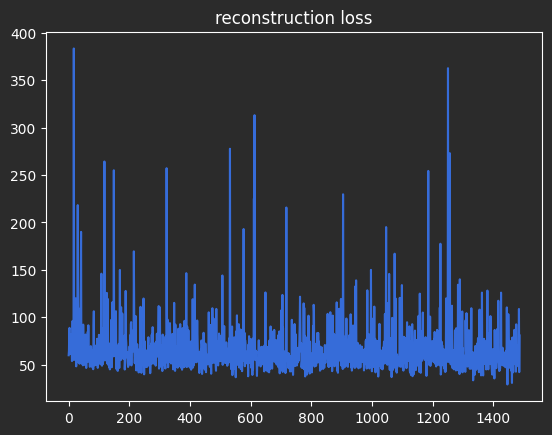

1488
step 1489  reconstruction loss 135.771159
step 1489  reconstruction loss 135.771159


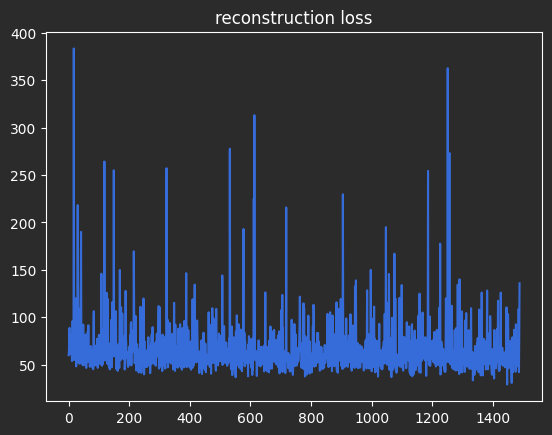

1489
step 1490  reconstruction loss 69.667905
step 1490  reconstruction loss 69.667905


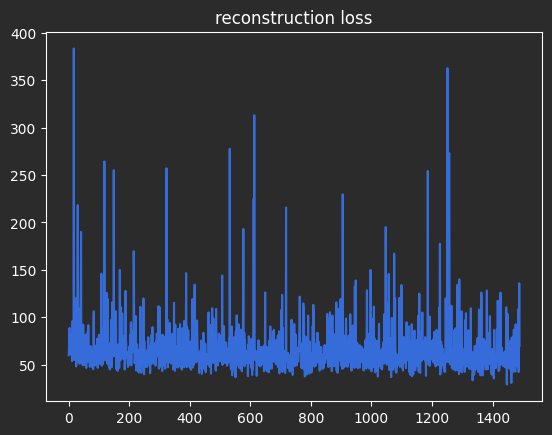

1490
step 1491  reconstruction loss 65.788794
step 1491  reconstruction loss 65.788794


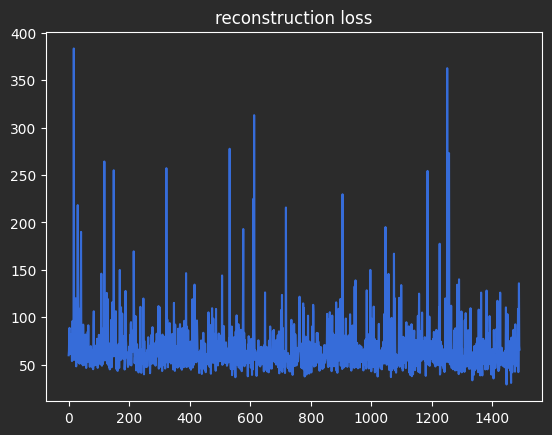

1491
step 1492  reconstruction loss 67.111988
step 1492  reconstruction loss 67.111988


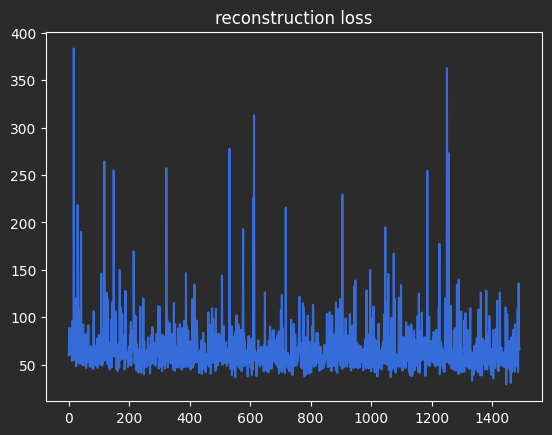

1492
step 1493  reconstruction loss 59.585942
step 1493  reconstruction loss 59.585942


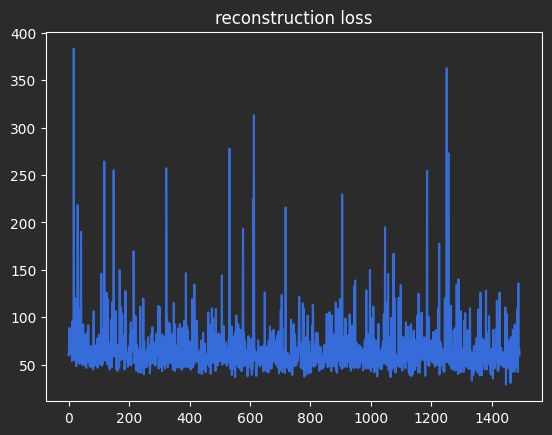

1493
step 1494  reconstruction loss 48.314954
step 1494  reconstruction loss 48.314954


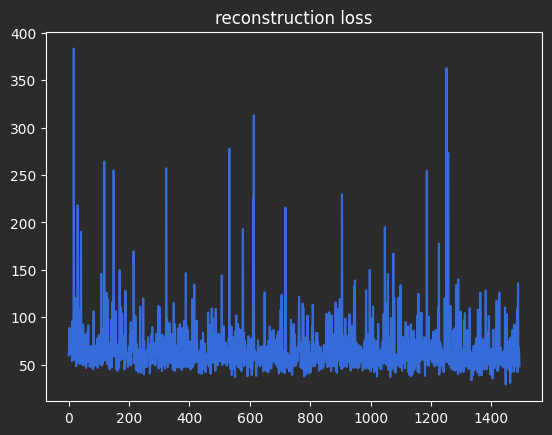

1494
step 1495  reconstruction loss 192.203367
step 1495  reconstruction loss 192.203367


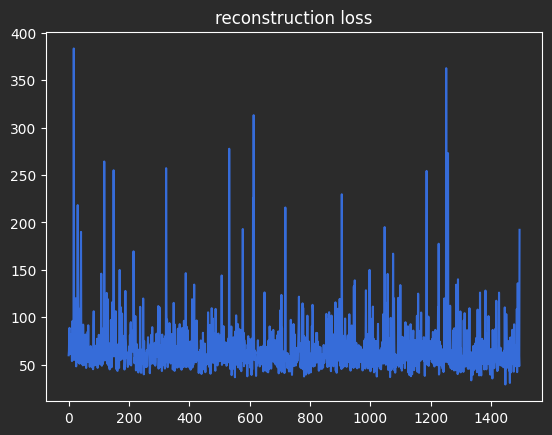

1495
step 1496  reconstruction loss 67.734854
step 1496  reconstruction loss 67.734854


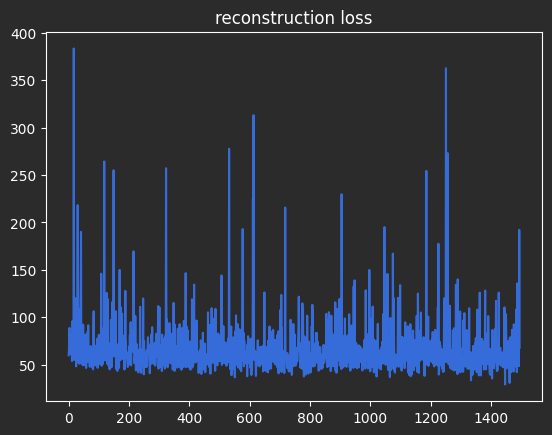

1496
step 1497  reconstruction loss 68.632489
step 1497  reconstruction loss 68.632489


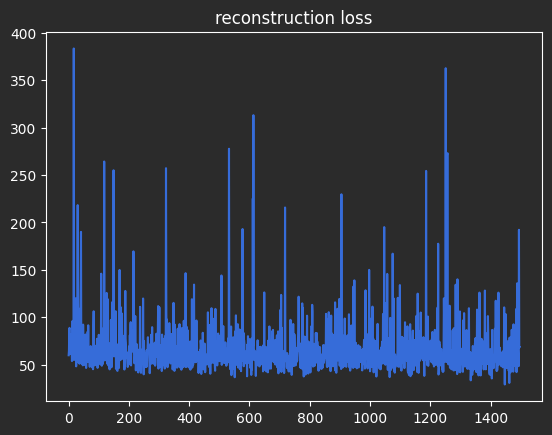

1497
step 1498  reconstruction loss 116.377287
step 1498  reconstruction loss 116.377287


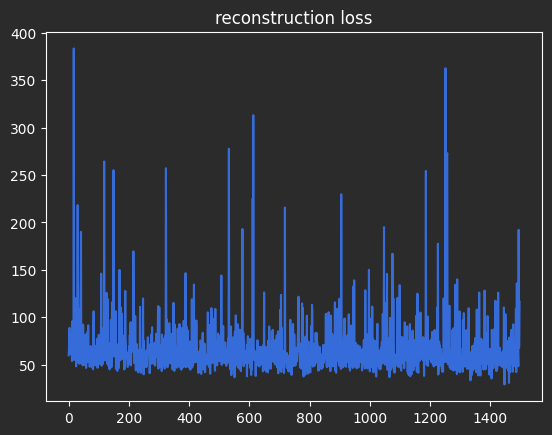

1498
step 1499  reconstruction loss 46.697456
step 1499  reconstruction loss 46.697456


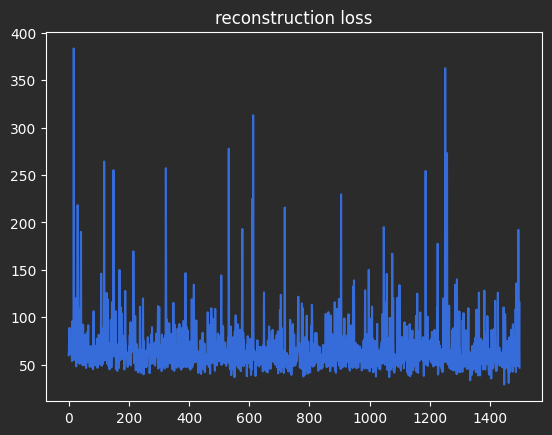

1499
step 1500  reconstruction loss 56.778039
step 1500  reconstruction loss 56.778039


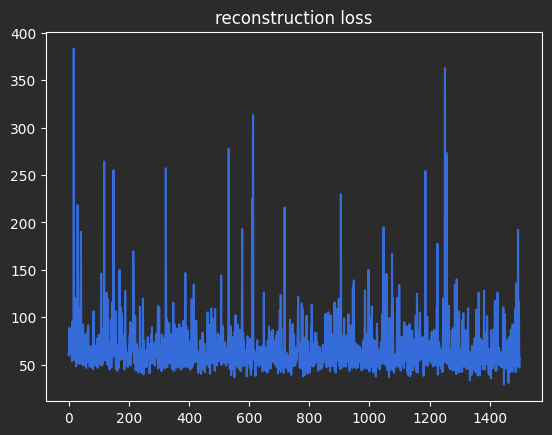

1500
step 1501  reconstruction loss 42.879324
step 1501  reconstruction loss 42.879324


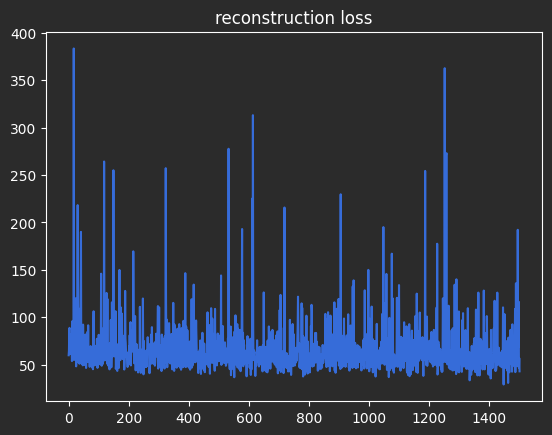

1501
step 1502  reconstruction loss 43.891084
step 1502  reconstruction loss 43.891084


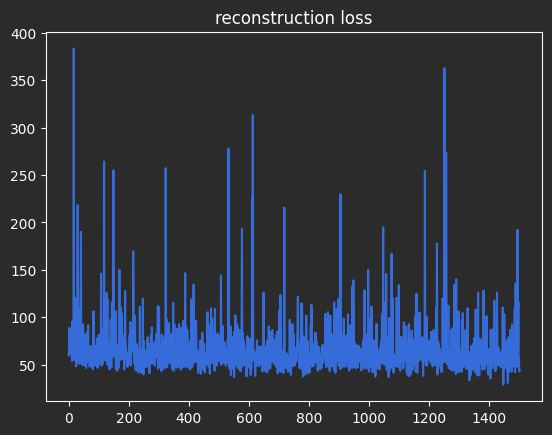

1502
step 1503  reconstruction loss 73.029061
step 1503  reconstruction loss 73.029061


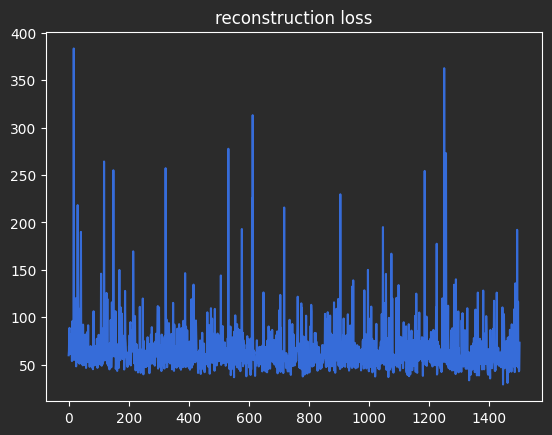

1503
step 1504  reconstruction loss 80.735313
step 1504  reconstruction loss 80.735313


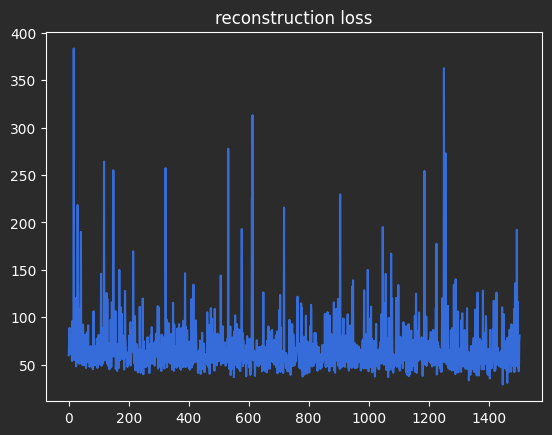

1504
step 1505  reconstruction loss 56.554639
step 1505  reconstruction loss 56.554639


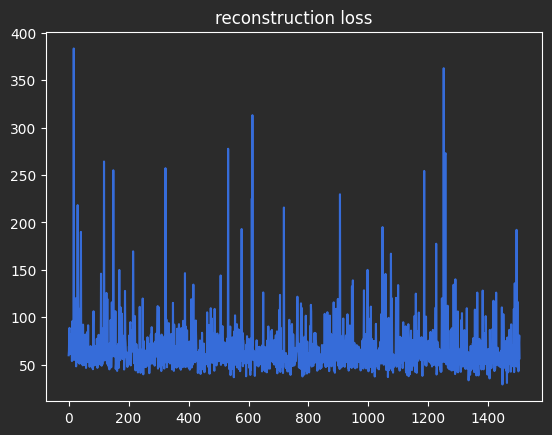

1505
step 1506  reconstruction loss 75.222896
step 1506  reconstruction loss 75.222896


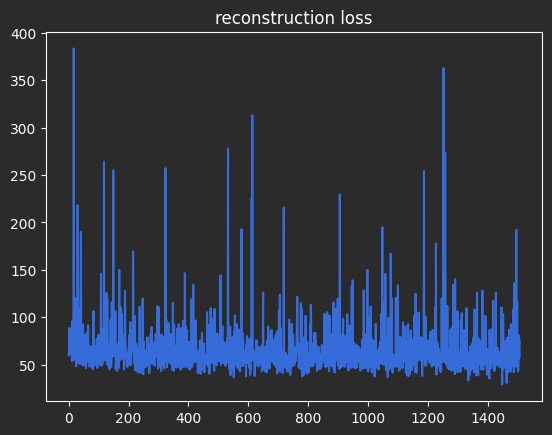

1506
step 1507  reconstruction loss 51.888005
step 1507  reconstruction loss 51.888005


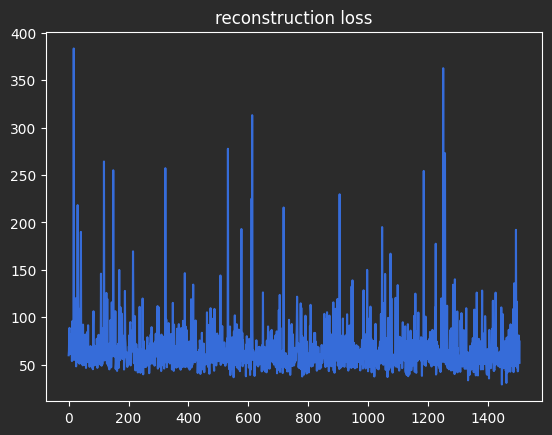

1507
step 1508  reconstruction loss 112.840175
step 1508  reconstruction loss 112.840175


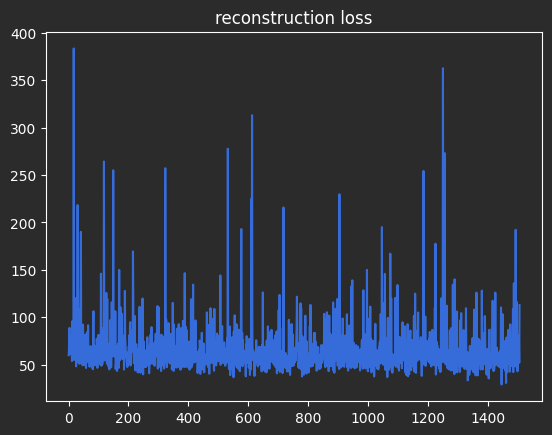

1508
step 1509  reconstruction loss 52.219351
step 1509  reconstruction loss 52.219351


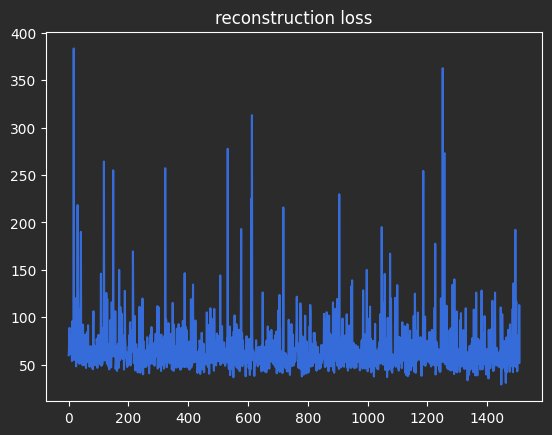

1509
step 1510  reconstruction loss 57.345894
step 1510  reconstruction loss 57.345894


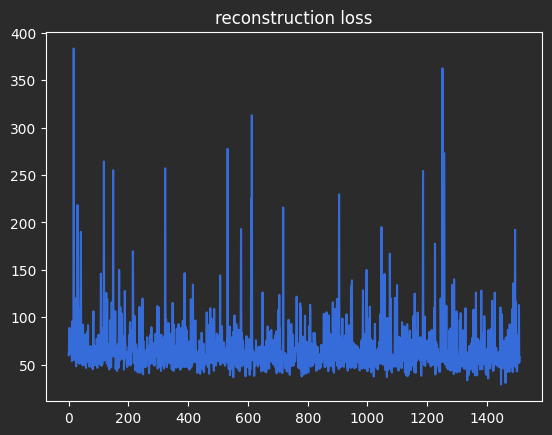

1510
step 1511  reconstruction loss 56.165961
step 1511  reconstruction loss 56.165961


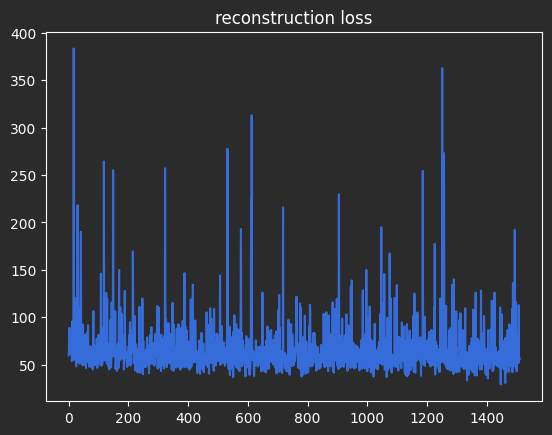

1511
step 1512  reconstruction loss 49.172169
step 1512  reconstruction loss 49.172169


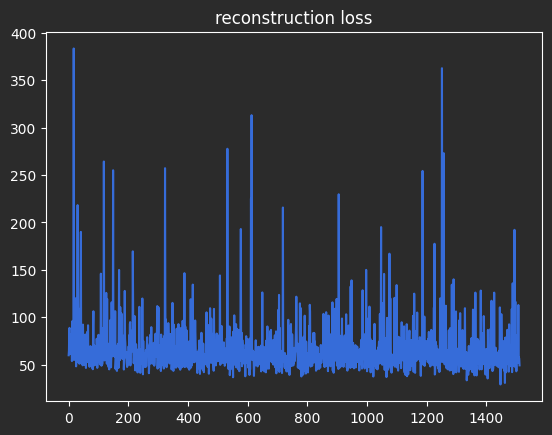

1512
step 1513  reconstruction loss 62.502583
step 1513  reconstruction loss 62.502583


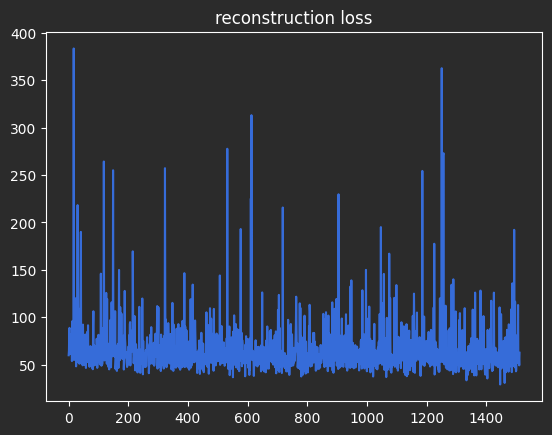

1513
step 1514  reconstruction loss 66.433039
step 1514  reconstruction loss 66.433039


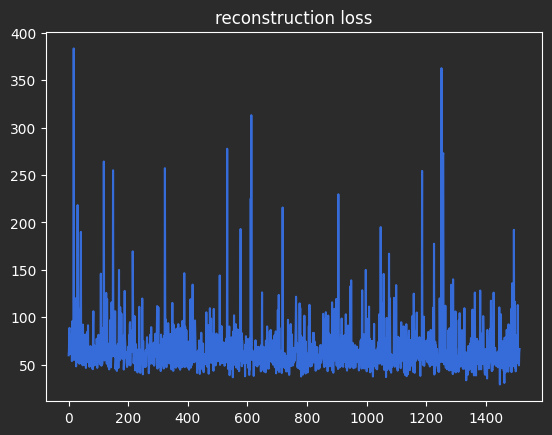

1514
step 1515  reconstruction loss 53.311512
step 1515  reconstruction loss 53.311512


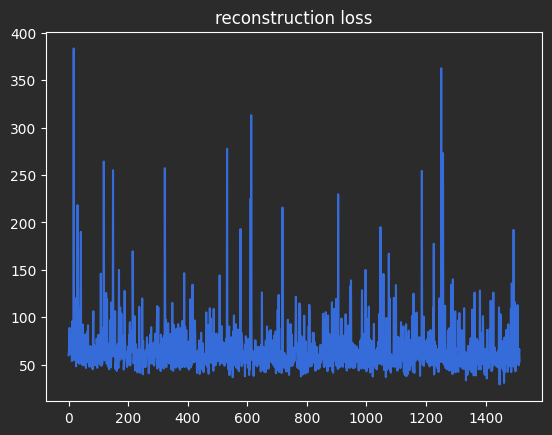

1515
step 1516  reconstruction loss 114.578883
step 1516  reconstruction loss 114.578883


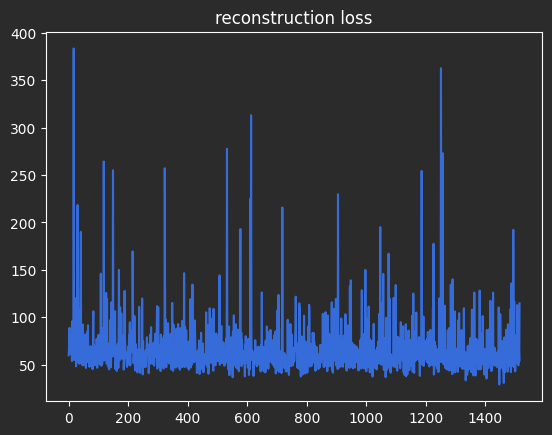

1516
step 1517  reconstruction loss 65.540515
step 1517  reconstruction loss 65.540515


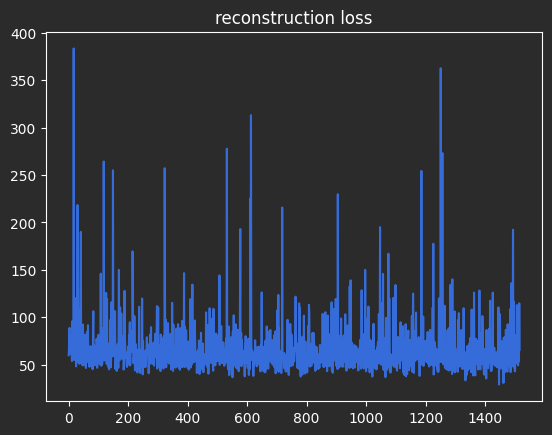

1517
step 1518  reconstruction loss 40.430092
step 1518  reconstruction loss 40.430092


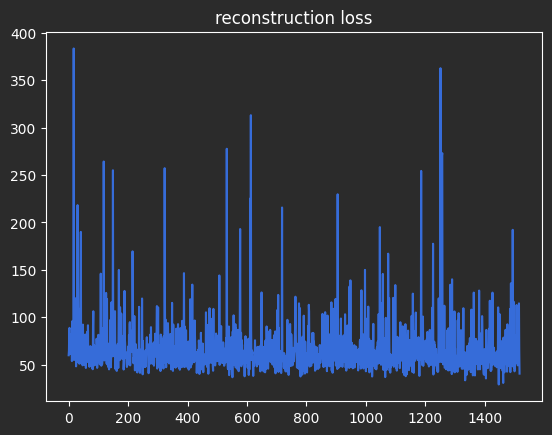

1518
step 1519  reconstruction loss 80.178313
step 1519  reconstruction loss 80.178313


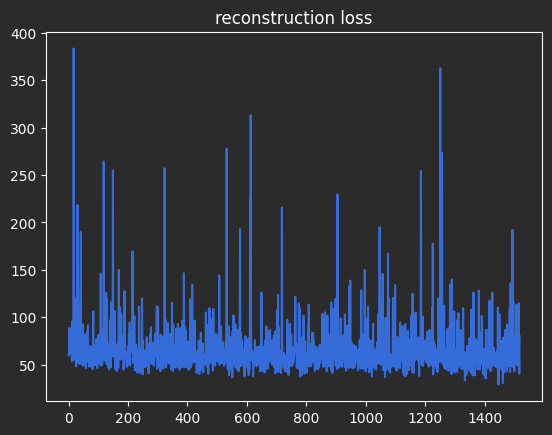

1519
step 1520  reconstruction loss 90.852432
step 1520  reconstruction loss 90.852432


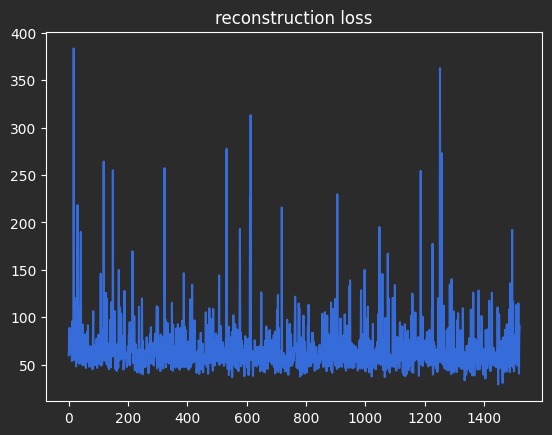

1520
step 1521  reconstruction loss 58.544981
step 1521  reconstruction loss 58.544981


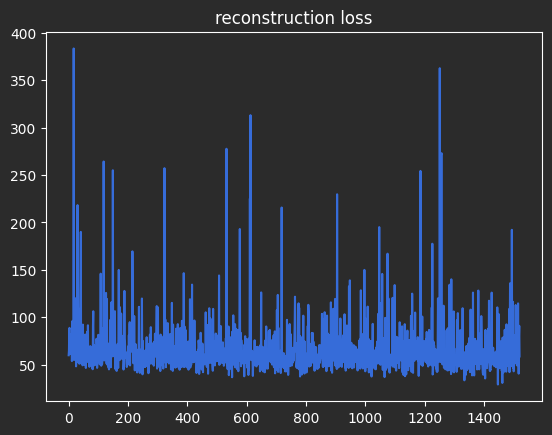

1521
step 1522  reconstruction loss 49.441145
step 1522  reconstruction loss 49.441145


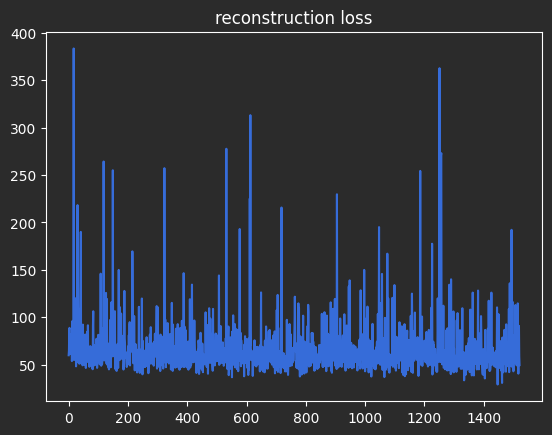

1522
step 1523  reconstruction loss 56.027573
step 1523  reconstruction loss 56.027573


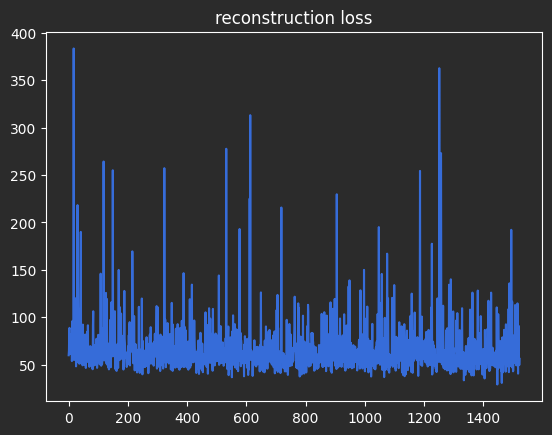

1523
step 1524  reconstruction loss 46.575109
step 1524  reconstruction loss 46.575109


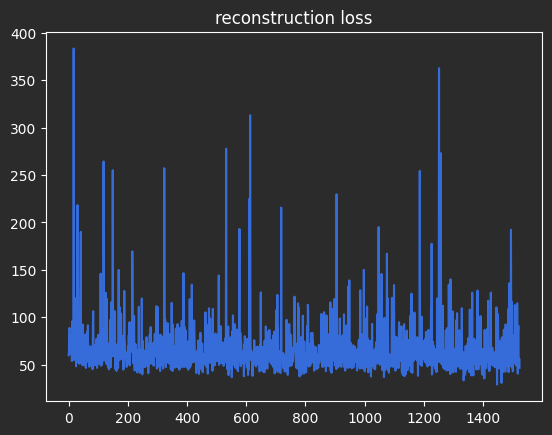

1524
step 1525  reconstruction loss 107.977379
step 1525  reconstruction loss 107.977379


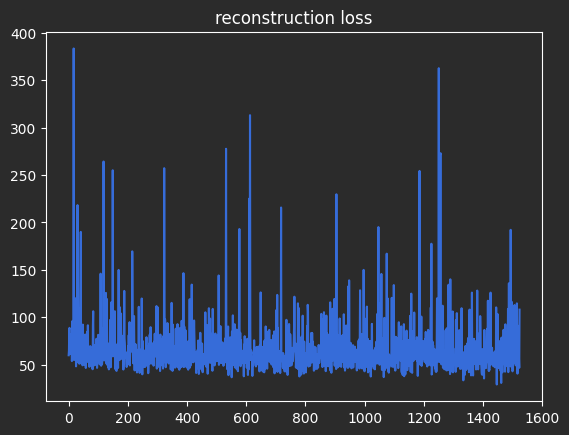

1525
step 1526  reconstruction loss 61.169786
step 1526  reconstruction loss 61.169786


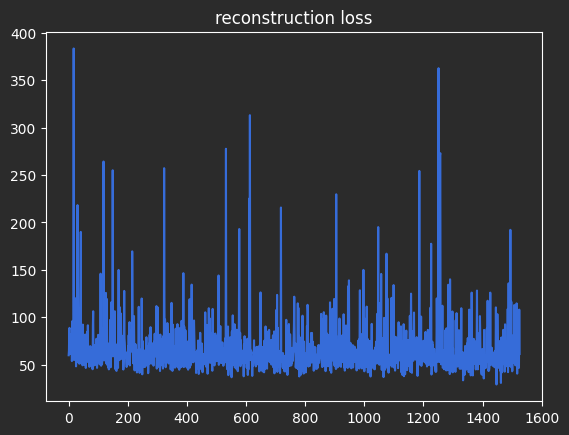

1526
step 1527  reconstruction loss 70.006967
step 1527  reconstruction loss 70.006967


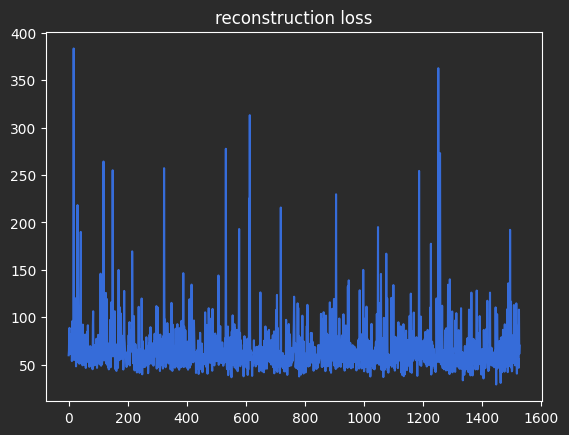

1527
step 1528  reconstruction loss 51.484401
step 1528  reconstruction loss 51.484401


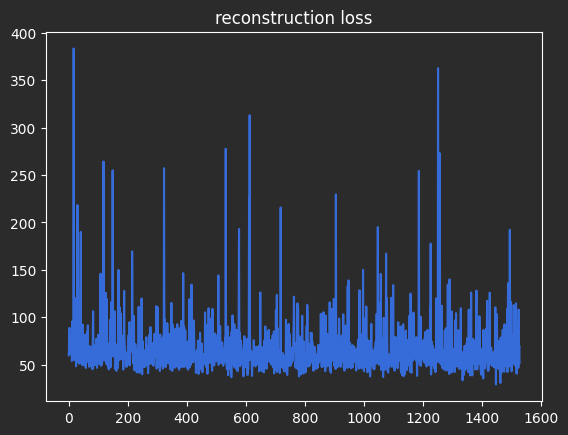

1528
step 1529  reconstruction loss 136.140581
step 1529  reconstruction loss 136.140581


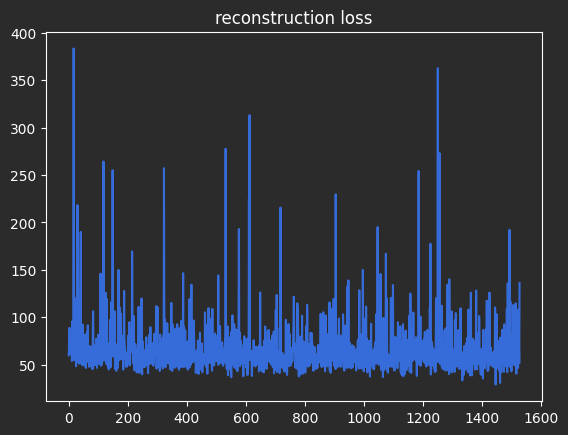

1529


KeyboardInterrupt: 

    [... skipping 1 hidden frame(s)]
  /var/folders/v1/q6fjybyj75s5vl9h5zylkbnw0000gp/T/ipykernel_33326/98476575.py(27)<module>()
     25             all_losses.append(reconstruction_loss.item())
     26 
---> 27             net.backward(loss.backward())
     28             optimizer.step(net.layers)
     29             print(f"step {step_i + 1:4d}  reconstruction loss {reconstruction_loss:.6f}")
  /Users/david/Library/CloudStorage/Dropbox/CODE/tools/ml-tools/src/ml_tools/models/neural_network.py(434)backward()
    432                 continue
    433 
--> 434             returned = node.layer.backward(gradients.pop(node))
    435             self._record_timing(node.name, "backward", time.perf_counter() - start)
    436             parts = returned if len(node.sources) > 1 else (returned,)
  /Users/david/Library/CloudStorage/Dropbox/CODE/tools/ml-tools/src/ml_tools/models/blocks.py(721)backward()
    719         dtwiddled = np.cumsum(dspectrum[:, ::-1], axis=1)[:, ::-1]
    720       

In [25]:
# AND this is how we train:

BATCH_SIZE = 2
EPOCHS = 10
STEPS_PER_SAMPLE = 1
LR = 4e-4
DIVI = 10

loss = MSELoss()
optimizer = Adam(LR)
all_losses = []

net.train()
for epoch in range(EPOCHS):
    for step_i, batch_st in enumerate(range(0, len(xs), BATCH_SIZE)):
        print(f"{step_i}")
        verbose = (step_i + 1) % DIVI == 0
        verbose = True

        _xs = xs[batch_st:batch_st+BATCH_SIZE, :, :]
        _pad = padding_mask[batch_st:batch_st+BATCH_SIZE, :]
        for _ in range(STEPS_PER_SAMPLE):
            x_prime = net.forward(_xs, mask=_pad)
            reconstruction_loss = loss.forward(prediction=x_prime, targets=_xs, mask=_pad)
            all_losses.append(reconstruction_loss.item())

            net.backward(loss.backward())
            optimizer.step(net.layers)
            print(f"step {step_i + 1:4d}  reconstruction loss {reconstruction_loss:.6f}")

        if verbose:
            print(f"step {step_i + 1:4d}  reconstruction loss {reconstruction_loss:.6f}")
            plt.plot(all_losses)
            plt.title("reconstruction loss")
            plt.show()

plt.plot(all_losses)
plt.title("reconstruction loss")
plt.show()

step    1  reconstruction loss 52.355666


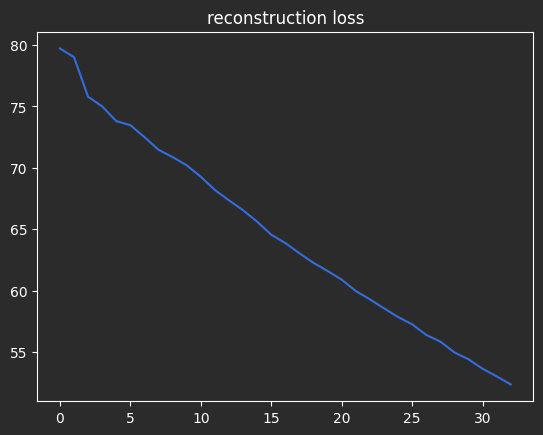

In [14]:
print(f"step {step_i + 1:4d}  reconstruction loss {reconstruction_loss:.6f}")
plt.plot(all_losses)
plt.title("reconstruction loss")
plt.show()

In [ ]:
plt.plot(x_prime[0, 3, :])
plt.show()
plt.plot(windowed_data[0, 3, :])
plt.plot((x_prime[0, 3, :] - windowed_data[0, 3, :]), color="red", alpha=0.2)
plt.show()

In [ ]:
print(net.summary())